# GP Posterior Coverage Analysis

This notebook recomputes the GP cross-validation predictions and checks posterior interval coverage for held-out raw RSSI samples. The GP is still fit on aggregated measurement-set means, but each held-out aggregate row is expanded back to its de-aggregated `df_clean.rssi_sample` values for the coverage check.

For raw-sample coverage, the posterior predictive variance includes the latent GP uncertainty plus the full indoor/outdoor observation-noise posterior variance. It does not divide the observation-noise variance by `obs_count_test`, because the target is now an individual raw RSSI sample rather than an aggregate mean.


In [1]:
import os
import sys
import time
from pathlib import Path

os.environ['CUDA_VISIBLE_DEVICES'] = '1'

# os.environ.setdefault('JAX_PLATFORMS', 'cpu')

import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

CWD = Path.cwd()
if CWD.name == 'milestone5':
    NOTEBOOK_DIR = CWD
elif (CWD / 'milestone5').exists() and CWD.name == 'code':
    NOTEBOOK_DIR = CWD / 'milestone5'
elif (CWD / 'code' / 'milestone5').exists():
    NOTEBOOK_DIR = CWD / 'code' / 'milestone5'
else:
    NOTEBOOK_DIR = CWD
CODE_DIR = NOTEBOOK_DIR.parent

sys.path.append(str(NOTEBOOK_DIR))
sys.path.append(str(CODE_DIR))

from gp import GaussianProcess, posterior_predictive_interval_summary
from gp_kernels import make_indoor_outdoor_mean, make_wifi_kernel


In [2]:
CV_SPLIT_TYPES = ['rand', 'geo']
CV_N_SPLITS = 5
CV_CHAINS = 2
CV_SAMPLES = 211
CV_CALIBRATION_ITERS = 30
CV_BURN_IN = 10
CV_THIN = 2
CV_JITTER_FACTOR = 5
CV_KEY_SEED = 305
CV_PREDICT_METHOD = 'sequential'

COVERAGE_LEVELS = (0.5, 0.8, 0.9, 0.95)
COVERAGE_TARGET = 'raw'
COVERAGE_KEY_SEED = 1305
COVERAGE_RESULTS_PATH = NOTEBOOK_DIR / 'cv_gibbs_raw_coverage_results.csv'
MSE_RESULTS_PATH = CODE_DIR / 'milestone4' / 'cv_gibbs_mse_results.csv'

REPO_DIR = CODE_DIR.parent
SEQUOIA_NONAN = (
    pd.read_csv(REPO_DIR / 'data' / 'sequoia_sets.csv')
    .loc[lambda df: df['rssi_set'].notna()]
    .reset_index(drop=True)
)
RAW_WIFI_SAMPLES = pd.read_csv(REPO_DIR / 'data' / 'df_clean.csv')
RAW_RSSI_BY_MID = {
    mid: group.sort_values('index')['rssi_sample'].dropna().to_numpy(dtype=float)
    for mid, group in RAW_WIFI_SAMPLES.groupby('mid', sort=False)
}


In [3]:

ap_form = "add"
ls_xy, ls_z, os_xyz, ls_t, os_t, ls_ap, os_ap = [0.05, 0.25, 20.0, 50.0, 0.0, 0.5, 0.0]
K = make_wifi_kernel(
    ap_form=ap_form,
    ls_xy=ls_xy,
    ls_z=ls_z,
    os_xyz=os_xyz,
    ls_t=ls_t,
    os_t=os_t,
    ls_ap=ls_ap,
    os_ap=os_ap,
)


def make_split_gp(X_split, y_split):
    return GaussianProcess(make_indoor_outdoor_mean(X_split, y_split), K)


In [4]:
def expand_raw_test_targets(test_idx, X_test, pred_means, pred_vars):
    test_idx = np.asarray(test_idx, dtype=int)
    if np.any(test_idx < 0) or np.any(test_idx >= len(SEQUOIA_NONAN)):
        raise ValueError('test_idx contains rows outside SEQUOIA_NONAN.')

    test_mids = SEQUOIA_NONAN.iloc[test_idx]['mid'].to_numpy()
    y_raw_parts = []
    parent_positions = []
    missing_mids = []

    for agg_pos, mid in enumerate(test_mids):
        samples = RAW_RSSI_BY_MID.get(mid)
        if samples is None or samples.size == 0:
            missing_mids.append(mid)
            continue
        y_raw_parts.append(samples)
        parent_positions.extend([agg_pos] * samples.size)

    if missing_mids:
        raise ValueError(f'Missing raw RSSI samples for {len(missing_mids)} held-out measurement sets.')

    parent_positions = np.asarray(parent_positions, dtype=int)
    y_raw = np.concatenate(y_raw_parts).astype(float)
    X_raw = np.asarray(X_test)[parent_positions]
    pred_means_raw = np.asarray(pred_means)[:, parent_positions]
    pred_vars_raw = np.asarray(pred_vars)[:, parent_positions]
    return y_raw, X_raw, pred_means_raw, pred_vars_raw, parent_positions


def evaluate_coverage_split(split_type, split_idx):
    split_dir = CODE_DIR / 'cv' / split_type

    X_cv_train = jnp.load(split_dir / f'X_train_{split_idx}.npy')
    y_cv_train = jnp.load(split_dir / f'y_train_{split_idx}.npy')
    obs_count_cv_train = jnp.load(split_dir / f'obs_count_train_{split_idx}.npy')
    obs_sse_cv_train = jnp.load(split_dir / f'obs_sse_train_{split_idx}.npy')

    X_cv_test = jnp.load(split_dir / f'X_test_{split_idx}.npy')
    y_cv_test = jnp.load(split_dir / f'y_test_{split_idx}.npy')
    obs_count_cv_test = jnp.load(split_dir / f'obs_count_test_{split_idx}.npy')
    test_idx = np.load(split_dir / f'test_idx_{split_idx}.npy')

    split_gp = make_split_gp(X_cv_train, y_cv_train)
    split_gp.fit(X_cv_train, y_cv_train, obs_count_cv_train, obs_sse_cv_train)

    key_offset = 0 if split_type == 'rand' else CV_N_SPLITS

    start = time.time()
    chain = split_gp.gibbs(
        key=jr.PRNGKey(CV_KEY_SEED + key_offset + split_idx),
        chains=CV_CHAINS,
        samples=CV_SAMPLES,
        calibration_iters=CV_CALIBRATION_ITERS,
        jitter_factor=CV_JITTER_FACTOR,
    )
    fit_elapsed = time.time() - start

    cov_chains = chain[1][:, CV_BURN_IN::CV_THIN, :]
    start = time.time()
    pred_means, pred_vars = split_gp.predict(X_cv_test, cov_chains, method=CV_PREDICT_METHOD)
    predict_elapsed = time.time() - start

    y_hat = pred_means.mean(axis=0)
    mse = jnp.mean((y_cv_test - y_hat) ** 2)

    y_raw_test, X_raw_test, pred_means_raw, pred_vars_raw, raw_parent_idx = expand_raw_test_targets(
        test_idx,
        X_cv_test,
        pred_means,
        pred_vars,
    )
    raw_counts_by_aggregate = np.bincount(raw_parent_idx, minlength=X_cv_test.shape[0])
    if not np.allclose(raw_counts_by_aggregate, np.asarray(obs_count_cv_test)):
        raise ValueError('Raw expansion counts do not match obs_count_test.')

    start = time.time()
    coverage = posterior_predictive_interval_summary(
        y_raw_test,
        pred_means_raw,
        pred_vars_raw,
        cov_chains=cov_chains,
        X_test=X_raw_test,
        levels=COVERAGE_LEVELS,
        target=COVERAGE_TARGET,
        random_state=COVERAGE_KEY_SEED + key_offset + split_idx,
    )
    coverage_elapsed = time.time() - start

    return {
        'split_type': split_type,
        'split_idx': split_idx,
        'n_train': int(X_cv_train.shape[0]),
        'n_test_aggregated': int(X_cv_test.shape[0]),
        'n_test_raw': int(y_raw_test.shape[0]),
        'raw_per_aggregate_mean': float(y_raw_test.shape[0] / X_cv_test.shape[0]),
        'mse_aggregated': float(mse),
        'fit_elapsed': fit_elapsed,
        'predict_elapsed': predict_elapsed,
        'coverage_elapsed': coverage_elapsed,
        'jitter': float(split_gp.jitter),
        **coverage,
    }


Running the next cell refits all GP CV folds. It is expected to take about as long as the existing GP CV MSE workflow.

In [5]:
coverage_results = []
for split_type in CV_SPLIT_TYPES:
    for split_idx in range(CV_N_SPLITS):
        print(f'Fitting {split_type} split {split_idx}')
        result = evaluate_coverage_split(split_type, split_idx)
        coverage_results.append(result)
        print(
            f"{split_type} split {split_idx}: "
            f"agg_MSE={result['mse_aggregated']:.4f}, "
            f"n_raw={result['n_test_raw']}, "
            f"coverage_95={result['coverage_95']:.3f}, "
            f"width_95={result['avg_width_95']:.2f}, "
            f"fit={result['fit_elapsed']:.1f}s, "
            f"predict={result['predict_elapsed']:.1f}s, "
            f"coverage={result['coverage_elapsed']:.1f}s"
        )

coverage_results_df = pd.DataFrame(coverage_results)
coverage_results_df.to_csv(COVERAGE_RESULTS_PATH, index=False)
coverage_results_df


Fitting rand split 0
rand split 0: agg_MSE=58.5233, n_raw=1561, coverage_95=0.928, width_95=29.55, fit=9.9s, predict=2.0s, coverage=0.4s
Fitting rand split 1
rand split 1: agg_MSE=64.7067, n_raw=1566, coverage_95=0.924, width_95=29.55, fit=8.4s, predict=1.6s, coverage=0.4s
Fitting rand split 2
rand split 2: agg_MSE=67.5802, n_raw=1565, coverage_95=0.922, width_95=29.57, fit=9.0s, predict=1.9s, coverage=0.4s
Fitting rand split 3
rand split 3: agg_MSE=62.0818, n_raw=1558, coverage_95=0.935, width_95=29.81, fit=8.3s, predict=1.6s, coverage=0.4s
Fitting rand split 4
rand split 4: agg_MSE=63.8077, n_raw=1557, coverage_95=0.918, width_95=29.52, fit=8.3s, predict=1.6s, coverage=0.4s
Fitting geo split 0
geo split 0: agg_MSE=77.2347, n_raw=1651, coverage_95=0.901, width_95=29.28, fit=8.4s, predict=1.8s, coverage=0.4s
Fitting geo split 1
geo split 1: agg_MSE=87.5921, n_raw=1521, coverage_95=0.866, width_95=29.82, fit=9.0s, predict=1.9s, coverage=0.4s
Fitting geo split 2
geo split 2: agg_MSE=133.

,split_type,split_idx,n_train,n_test_aggregated,n_test_raw,raw_per_aggregate_mean,mse_aggregated,fit_elapsed,predict_elapsed,coverage_elapsed,...,normal_coverage_80,normal_avg_width_80,coverage_90,avg_width_90,normal_coverage_90,normal_avg_width_90,coverage_95,avg_width_95,normal_coverage_95,normal_avg_width_95
0,rand,0,2093,524,1561,2.979008,58.523254,9.891831,2.025039,0.433990,...,0.809737,19.781555,0.884689,25.023720,0.893658,25.389349,0.927611,29.549738,0.933376,30.253273
1,rand,1,2093,524,1566,2.988550,64.706718,8.356176,1.610067,0.437748,...,0.795658,19.713568,0.873563,25.016603,0.879949,25.302090,0.924010,29.553316,0.936143,30.149302
2,rand,2,2094,523,1565,2.992352,67.580200,9.049392,1.850340,0.406170,...,0.796166,19.756142,0.868371,25.010313,0.879872,25.356733,0.922045,29.572398,0.927796,30.214411
3,rand,3,2094,523,1558,2.978967,62.081760,8.273561,1.603426,0.438087,...,0.789474,19.931751,0.888318,25.198428,0.903081,25.582125,0.935173,29.814915,0.945443,30.482983
4,rand,4,2094,523,1557,2.977055,63.807705,8.311944,1.593945,0.403444,...,0.789981,19.769896,0.869621,24.961273,0.883109,25.374386,0.917791,29.515397,0.921644,30.235449
5,geo,0,2064,553,1651,2.985533,77.234726,8.435863,1.812216,0.411914,...,0.748637,19.595308,0.838280,24.804670,0.847971,25.150303,0.901272,29.280396,0.905512,29.968439
6,geo,1,2107,510,1521,2.982353,87.592087,9.023347,1.930018,0.413712,...,0.734385,19.952972,0.819198,25.202680,0.823800,25.609360,0.865878,29.824917,0.879684,30.515438
7,geo,2,2013,604,1809,2.995033,133.175217,8.453060,1.808505,0.415539,...,0.705362,20.038862,0.791045,25.285546,0.805417,25.719601,0.839690,29.866104,0.846324,30.646795
8,geo,3,2092,525,1566,2.982857,55.995155,8.876573,1.868025,0.036641,...,0.833972,21.095808,0.915070,26.655156,0.924649,27.076176,0.961047,31.521548,0.969349,32.263256
9,geo,4,2192,425,1260,2.964706,60.761387,9.247416,1.924676,0.449239,...,0.783333,19.369801,0.870635,24.528640,0.878571,24.860872,0.915079,29.030567,0.915079,29.623556


In [19]:
coverage_results_df[
lambda df: (df['split_type'] == "geo") & (df['split_idx'] == 0)
].pipe(
    lambda df: df[[c for c in df.columns if c.startswith("coverage") or "width" in c]]
)

,coverage_elapsed,coverage_50,avg_width_50,normal_avg_width_50,coverage_80,avg_width_80,normal_avg_width_80,coverage_90,avg_width_90,normal_avg_width_90,coverage_95,avg_width_95,normal_avg_width_95
5,0.411914,0.457904,10.225037,10.31315,0.734101,19.377561,19.595308,0.83828,24.80467,25.150303,0.901272,29.280396,29.968439


In [6]:
coverage_results_df = pd.read_csv(COVERAGE_RESULTS_PATH)
coverage_cols = [f'coverage_{int(level * 100)}' for level in COVERAGE_LEVELS]
normal_coverage_cols = [f'normal_coverage_{int(level * 100)}' for level in COVERAGE_LEVELS]
width_cols = [f'avg_width_{int(level * 100)}' for level in COVERAGE_LEVELS]
normal_width_cols = [f'normal_avg_width_{int(level * 100)}' for level in COVERAGE_LEVELS]
diag_cols = ['n_test_aggregated', 'n_test_raw', 'raw_per_aggregate_mean', 'mean_predictive_sd']

coverage_results_df.groupby('split_type')[coverage_cols + normal_coverage_cols + width_cols + normal_width_cols + diag_cols].mean()


,coverage_50,coverage_80,coverage_90,coverage_95,normal_coverage_50,normal_coverage_80,normal_coverage_90,normal_coverage_95,avg_width_50,avg_width_80,avg_width_90,avg_width_95,normal_avg_width_50,normal_avg_width_80,normal_avg_width_90,normal_avg_width_95,n_test_aggregated,n_test_raw,raw_per_aggregate_mean,mean_predictive_sd
split_type,,,,,,,,,,,,,,,,,,,,
geo,0.473291,0.752503,0.846846,0.896593,0.479253,0.761138,0.856082,0.90319,10.456016,19.791908,25.295338,29.904707,10.531696,20.010550,25.683262,30.603497,523.4,1561.4,2.982097,7.807158
rand,0.511992,0.787881,0.876913,0.925326,0.517246,0.796203,0.887934,0.93288,10.347288,19.607601,25.042068,29.601153,10.415924,19.790582,25.400937,30.267083,523.4,1561.4,2.983186,7.721337


In [7]:
coverage_results_df = pd.read_csv(COVERAGE_RESULTS_PATH)
coverage_cols = [f'coverage_{int(level * 100)}' for level in COVERAGE_LEVELS]
width_cols = [f'avg_width_{int(level * 100)}' for level in COVERAGE_LEVELS]

coverage_results_df.groupby('split_type')[coverage_cols + width_cols].mean()

,coverage_50,coverage_80,coverage_90,coverage_95,avg_width_50,avg_width_80,avg_width_90,avg_width_95
split_type,,,,,,,,
geo,0.473291,0.752503,0.846846,0.896593,10.456016,19.791908,25.295338,29.904707
rand,0.511992,0.787881,0.876913,0.925326,10.347288,19.607601,25.042068,29.601153


In [8]:
if MSE_RESULTS_PATH.exists():
    mse_results = pd.read_csv(MSE_RESULTS_PATH)
    coverage_with_mse = coverage_results_df.merge(
        mse_results[['split_type', 'split_idx', 'mse']],
        on=['split_type', 'split_idx'],
        how='left',
        suffixes=('', '_previous'),
    )
else:
    coverage_with_mse = coverage_results_df.copy()

coverage_with_mse

,split_type,split_idx,n_train,n_test_aggregated,n_test_raw,raw_per_aggregate_mean,mse_aggregated,fit_elapsed,predict_elapsed,coverage_elapsed,...,normal_avg_width_80,coverage_90,avg_width_90,normal_coverage_90,normal_avg_width_90,coverage_95,avg_width_95,normal_coverage_95,normal_avg_width_95,mse
0,rand,0,2093,524,1561,2.979008,58.523254,9.891831,2.025039,0.433990,...,19.781555,0.884689,25.023720,0.893658,25.389349,0.927611,29.549738,0.933376,30.253273,42.191994
1,rand,1,2093,524,1566,2.988550,64.706718,8.356176,1.610067,0.437748,...,19.713568,0.873563,25.016603,0.879949,25.302090,0.924010,29.553316,0.936143,30.149302,50.380039
2,rand,2,2094,523,1565,2.992352,67.580200,9.049392,1.850340,0.406170,...,19.756142,0.868371,25.010313,0.879872,25.356733,0.922045,29.572398,0.927796,30.214411,52.541313
3,rand,3,2094,523,1558,2.978967,62.081760,8.273561,1.603426,0.438087,...,19.931751,0.888318,25.198428,0.903081,25.582125,0.935173,29.814915,0.945443,30.482983,52.665833
4,rand,4,2094,523,1557,2.977055,63.807705,8.311944,1.593945,0.403444,...,19.769896,0.869621,24.961273,0.883109,25.374386,0.917791,29.515397,0.921644,30.235449,48.455055
5,geo,0,2064,553,1651,2.985533,77.234726,8.435863,1.812216,0.411914,...,19.595308,0.838280,24.804670,0.847971,25.150303,0.901272,29.280396,0.905512,29.968439,75.785660
6,geo,1,2107,510,1521,2.982353,87.592087,9.023347,1.930018,0.413712,...,19.952972,0.819198,25.202680,0.823800,25.609360,0.865878,29.824917,0.879684,30.515438,75.628685
7,geo,2,2013,604,1809,2.995033,133.175217,8.453060,1.808505,0.415539,...,20.038862,0.791045,25.285546,0.805417,25.719601,0.839690,29.866104,0.846324,30.646795,124.133408
8,geo,3,2092,525,1566,2.982857,55.995155,8.876573,1.868025,0.036641,...,21.095808,0.915070,26.655156,0.924649,27.076176,0.961047,31.521548,0.969349,32.263256,63.523743
9,geo,4,2192,425,1260,2.964706,60.761387,9.247416,1.924676,0.449239,...,19.369801,0.870635,24.528640,0.878571,24.860872,0.915079,29.030567,0.915079,29.623556,62.072765


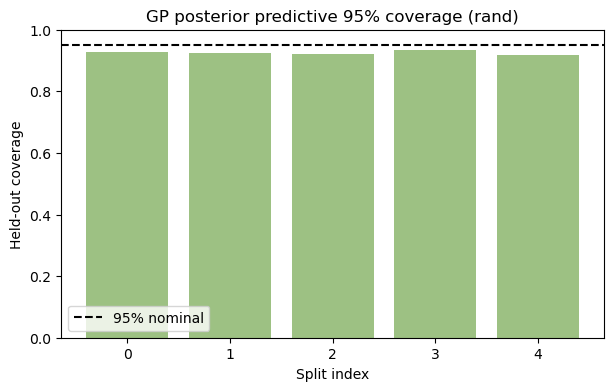

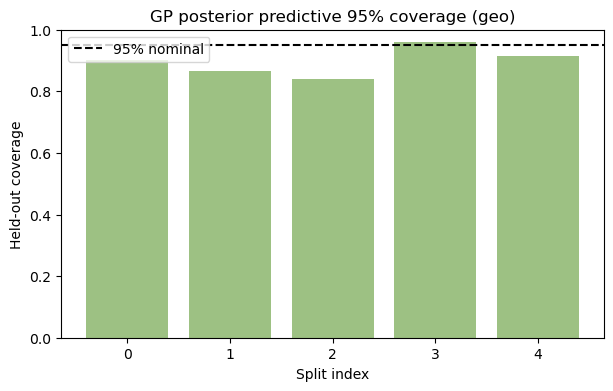

In [9]:
def plot_coverage(split_type, level='95'):
    subset = coverage_results_df[coverage_results_df['split_type'] == split_type].sort_values('split_idx')
    nominal = int(level) / 100

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(subset['split_idx'], subset[f'coverage_{level}'], color=(157/255, 193/255, 131/255))
    ax.axhline(nominal, color='black', linestyle='--', linewidth=1.5, label=f'{nominal:.0%} nominal')
    ax.set_ylim(0, 1)
    ax.set_xlabel('Split index')
    ax.set_ylabel('Held-out coverage')
    ax.set_title(f'GP posterior predictive {level}% coverage ({split_type})')
    ax.legend()
    plt.show()


plot_coverage('rand', '95')
plot_coverage('geo', '95')

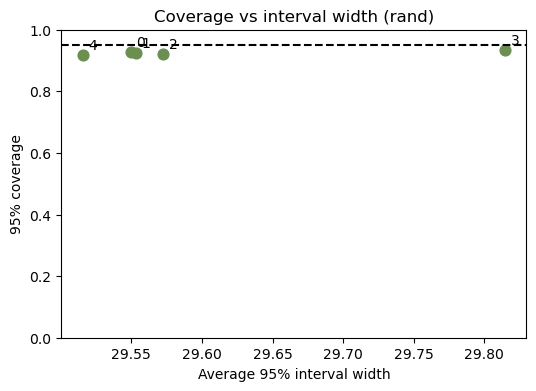

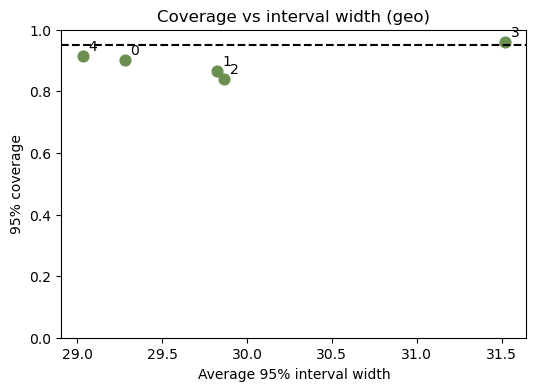

In [10]:
def plot_coverage_vs_width(split_type, level='95'):
    subset = coverage_results_df[coverage_results_df['split_type'] == split_type].sort_values('split_idx')

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.scatter(subset[f'avg_width_{level}'], subset[f'coverage_{level}'], s=60, color=(107/255, 143/255, 81/255))
    for _, row in subset.iterrows():
        ax.annotate(int(row['split_idx']), (row[f'avg_width_{level}'], row[f'coverage_{level}']), xytext=(4, 4), textcoords='offset points')
    ax.axhline(int(level) / 100, color='black', linestyle='--', linewidth=1.5)
    ax.set_ylim(0, 1)
    ax.set_xlabel(f'Average {level}% interval width')
    ax.set_ylabel(f'{level}% coverage')
    ax.set_title(f'Coverage vs interval width ({split_type})')
    plt.show()


plot_coverage_vs_width('rand', '95')
plot_coverage_vs_width('geo', '95')